In [1]:
import os, sys 
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from typing import Optional, Union, List, Tuple, Dict

current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../"))
project_root
sys.path.append(project_root)

# from vllm.v1.core.sched.step_estimator import StepStats
# from vllm.v1.core.sched.step_estimator.models.light_gradient_boost_machine import (
#     LightGradientBoostMachine,
# )
# from vllm.v1.core.sched.step_estimator.models.utils import transform_features

In [2]:
# class LightGradientBoostMachine(BaseModel):
#     def __init__(self, 
#                  model_path: str, 
#                  features_path: str,
#                  features: list[str]):
#         logger.info(f"Creating LightGradientBoostMachine with model_path: {model_path}, features_path: {features_path}, features: {features}")
#         super().__init__(model_path, features_path, features)
        
#     def predict(self, X: Union[StepStats, list[StepStats]]) -> Union[float, list[float]]:
#         X_df = transform_features(X, self.features)
#         # logger.debug(f"Predicting with features: {X_df}")
#         predictions = self.model.predict(X_df) * (X.output_length if isinstance(X, StepStats) else X[0].output_length)
#         return predictions[0] if len(predictions) == 1 else predictions

#     def train(self, X, y):
#         # TODO
#         self.model.fit(X, y)

#     def save_model(self, file_path):
#         # TODO
#         if hasattr(self.model, "booster_"):
#             # sklearn wrapper — extract underlying Booster
#             self.model.booster_.save_model(file_path)
#         elif isinstance(self.model, lgb.Booster):
#             # already a Booster (if loaded directly)
#             self.model.save_model(file_path)
#         else:
#             raise RuntimeError("Model has no Booster to save.")
#         logger.info(f"Saved LightGBM model to {file_path}")
            

#     def load_model(self):
#         # if model file doesn't exist, train from scratch
#         if not os.path.exists(self.model_path):
#             logger.debug(f"Model file {self.model_path} does not exist. Training from scratch.")
#             self.model = lgb.LGBMRegressor(
#             objective="regression",
#             metric="rmse",
#             # n_estimators=200,
#             # learning_rate=0.1,
#             # num_leaves=64,
#             verbose=-1,
#             )
#         else:
#             self.model = lgb.Booster(model_file=self.model_path)

#     def print_importance(self): 

#         importances = self.model.booster_.feature_importance()
#         feature_names = self.model.booster_.feature_name()

#         importance_df = pd.DataFrame({
#             'feature': feature_names,
#             'importance': importances
#         }).sort_values(by='importance', ascending=False)

#         print(importance_df)

#         # lgb.plot_importance(self.model, importance_type='split', max_num_features=20)

In [3]:
# # ----------------------------
# # Helpers
# # ----------------------------
# def _step_key_from_record(rec: dict) -> Tuple[str, int]:
#     # Unique per-step identifier
#     return (rec["id"], rec["num_denoise_ran"])

# def _step_key_from_stats(s: StepStats) -> Tuple[str, int]:
#     return (s.id, s.num_denoise_ran)


# # -----------------------------------------------------
# # 1) Read line-delimited JSON into StepStats
# # -----------------------------------------------------
# def load_stepstats(path: str) -> List[StepStats]:
#     """Load one step_data file (JSON lines) into a list of StepStats objects."""
#     stats: List[StepStats] = []
#     with open(path, "r") as f:
#         for line in f:
#             if not line.strip():
#                 continue
#             r = json.loads(line)
#             s = StepStats(
#                 id=r["id"],
#                 num_denoise_ran=r["num_denoise_ran"],
#                 num_unmasked_tokens=r["num_unmasked_tokens"],
#                 num_cur_unmasked_tokens=r["num_cur_unmasked_tokens"],
#                 output_length=r["output_length"],
#                 block=r["block"],
#                 block_num_denoise_ran=r["block_num_denoise_ran"],
#                 block_num_unmasked_tokens=r["block_num_unmasked_tokens"],
#                 block_size=r["block_size"],
#                 confidences=r.get("confidences"),
#                 cur_tokens_unmasked=r.get("cur_tokens_unmasked"),
#                 confidence_threshold=r.get("confidence_threshold"),
#             )
#             stats.append(s)
#     return stats


# # -----------------------------------------------------
# # 2) Compute per-step targets (ratio & steps)
# # -----------------------------------------------------
# def compute_targets(paths: List[str]) -> pd.DataFrame:
#     """
#     Return a DataFrame with a unique key per step (id, num_denoise_ran), plus:
#       - denoise_ratio (target used for training)
#       - output_length (for conversion to steps)
#       - num_unmasked_tokens (for plotting)
#     """
#     df = pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

#     for i in range(len(df)): 
#         confidences = df.iloc[i]["confidences"]
#         # print(np.mean(confidences), np.median(confidences), np.percentile(confidences, 25), np.percentile(confidences, 75)) 

#     # Final denoise (per id) to compute how many steps are left at each step
#     final_denoise = df.groupby("id")["num_denoise_ran"].transform("max")
    
#     # df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]
#     # Number of progress left
#     df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]

#     # Unique step key to align targets with StepStats lists
#     df["__key_id"] = df["id"]
#     df["__key_step"] = df["num_denoise_ran"]

#     return df[
#         [
#             "__key_id",
#             "__key_step",
#             "id",
#             "num_denoise_ran",
#             "denoise_ratio",
#             "output_length",
#             "num_unmasked_tokens",
#         ]
#     ]


# # -----------------------------------------------------
# # 3) Training & evaluation using StepStats + wrapper
# # -----------------------------------------------------
# def train_and_evaluate_stepstats(
#     train_path: Union[str, List[str]],
#     test_path: Optional[Union[str, List[str]]] = None,
#     train_from_scratch: bool = True,
# ) -> None:
#     """
#     Pipeline:
#       - Load ALL data (train + optional test files)
#       - Build targets for ALL steps
#       - Split ids into train/test (80/20 if no explicit test files)
#       - Filter StepStats by ids to avoid leakage
#       - transform_features(...) -> X_train/X_test aligned to StepStats order
#       - Build y_train/y_test by mapping keys (id, num_denoise_ran) to denoise_ratio
#       - Train wrapper; Predict (steps); Evaluate in steps; Also report ratios
#     """
#     included_features = [
#         "confidence_threshold",
#         "full_progress",
#         "full_unmask_progress",
#         "block_progress",
#         "block_unmask_progress",
#         "full_cur_unmask_progress",
#         "lower_quartile_confidences",
#         "upper_quartile_confidences",
#         "mean_confidences", 
#         "median_confidences", 
#     ]

#     # Normalize inputs
#     if isinstance(train_path, str):
#         train_path = [train_path]
#     if test_path is not None and isinstance(test_path, str):
#         test_path = [test_path]

#     # ----- Load all paths and targets -----
#     all_paths: List[str] = [*train_path, *(test_path or [])]
#     targets_df = compute_targets(all_paths)

#     # Choose split ids
#     if test_path is None:
#         unique_ids = targets_df["id"].unique()
#         unique_ids = np.sort(unique_ids)
#         train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)
#         title_suffix = " (80/20 split)"
#         # print(train_ids)
#         # print(len(train_ids))
#     else:
#         # Explicit split by files
#         train_ids = (
#             pd.concat([pd.read_json(p, lines=True)["id"] for p in train_path], ignore_index=True)
#             .unique()
#         )
#         test_ids = (
#             pd.concat([pd.read_json(p, lines=True)["id"] for p in test_path], ignore_index=True)
#             .unique()
#         )
#         title_suffix = f" (Train on {', '.join(train_path)}, Test on {', '.join(test_path)})"

#     train_id_set = set(train_ids)
#     test_id_set = set(test_ids)

#     # ----- Load *all* StepStats (from all_paths), then filter by split ids -----
#     all_stats: List[StepStats] = []
#     for p in all_paths:
#         all_stats.extend(load_stepstats(p))

#     train_stats = [s for s in all_stats if s.id in train_id_set]
#     test_stats = [s for s in all_stats if s.id in test_id_set]


#     # Safety checks
#     assert set(s.id for s in train_stats).issubset(train_id_set)
#     assert set(s.id for s in test_stats).issubset(test_id_set)

#     # ----- Build key → target map (ratio) -----
#     # Keys match (id, num_denoise_ran) as used in StepStats
#     targets_df["__key"] = list(zip(targets_df["__key_id"], targets_df["__key_step"]))
#     target_map: Dict[Tuple[str, int], float] = dict(
#         zip(targets_df["__key"].tolist(), targets_df["denoise_ratio"].tolist())
#     )

#     # ----- Transform StepStats → features (keep exact order) -----
#     X_train = transform_features(train_stats, included_features).copy()
#     X_test = transform_features(test_stats, included_features).copy() if test_stats else None

#     # Handle missing features (e.g., None confidence_threshold)
#     # X_train = X_train.fillna(0.0)
#     # if X_test is not None:
#     #     X_test = X_test.fillna(0.0)
#     print(f"X_train: {X_train}")
#     print(f"Feature list: {X_train.columns}")
#     print(f"X_test: {X_test}")
#     print(f"target_map: {list(target_map.items())[:5]}")

#     # ----- Build aligned y vectors following the StepStats order -----
#     y_train_ratio = np.array([target_map[_step_key_from_stats(s)] for s in train_stats], dtype=float)
#     y_test_ratio = np.array([target_map[_step_key_from_stats(s)] for s in test_stats], dtype=float) if test_stats else None

#     print(f"Training samples: {len(X_train)}, Testing samples: {0 if X_test is None else len(X_test)}")

#     train_from_scratch = True
#     model_dir = "models/lgb_kiet"
#     os.makedirs(model_dir, exist_ok=True)
#     model_path = os.path.join(model_dir, "model2.bin")
#     features_path = os.path.join(model_dir, "features.txt")
#     if train_from_scratch and os.path.exists(model_path):
#         os.remove(model_path)
#     if train_from_scratch and os.path.exists(features_path):
#         os.remove(features_path)

#     model = LightGradientBoostMachine(model_path, features_path, included_features)
#     model.train(X_train, y_train_ratio)
#     model.save_model(model_path)
#     model.print_importance()

#     with open(features_path, "w") as f:
#         for feat in included_features:
#             f.write(f"{feat}\n")

#     # -------------------------------------------------
#     # Evaluate (predict using StepStats API)
#     # model.predict(...) returns STEPS; compare in steps.
#     # -------------------------------------------------
#     if not test_stats:
#         print("No separate test set; skipping evaluation.")
#         return

#     y_pred_steps = np.asarray(model.predict(test_stats), dtype=float)

#     # Build arrays for output_length and num_unmasked_tokens (from test_stats order)
#     test_output_lengths = np.array([s.output_length for s in test_stats], dtype=float)
#     test_num_unmasked = np.array([s.num_unmasked_tokens for s in test_stats], dtype=float)

#     # Convert ground-truth ratio → steps, aligned to test_stats order
#     y_test_steps = y_test_ratio * test_output_lengths

#     # Metrics (primary: steps)
#     rmse_steps = root_mean_squared_error(y_test_steps, y_pred_steps)
#     r2_steps = r2_score(y_test_steps, y_pred_steps)

#     # Also compute ratios for diagnostics
#     # Avoid div-by-zero: output_length should be >0, but guard anyway
#     safe_output_lengths = np.where(test_output_lengths == 0, 1.0, test_output_lengths)
#     y_pred_ratio = y_pred_steps / safe_output_lengths

#     rmse_ratio = root_mean_squared_error(y_test_ratio, y_pred_ratio)
#     r2_ratio = r2_score(y_test_ratio, y_pred_ratio)

#     print(f"RMSE (steps): {rmse_steps:.4f}")
#     print(f"R^2   (steps): {r2_steps:.4f}")
#     print(f"RMSE (ratio): {rmse_ratio:.4f}")
#     print(f"R^2   (ratio): {r2_ratio:.4f}")

#     # -------------------------------------------------
#     # Plots
#     # -------------------------------------------------
#     # Ratio scatter
#     plt.figure(figsize=(6, 5))
#     plt.scatter(y_test_ratio, y_pred_ratio, alpha=0.3)
#     plt.xlabel("Actual Denoise Ratio")
#     plt.ylabel("Predicted Denoise Ratio")
#     plt.title(f"Predicted vs Actual Denoise Ratio{title_suffix}")
#     lim_lo = float(min(y_test_ratio.min(), y_pred_ratio.min()))
#     lim_hi = float(max(y_test_ratio.max(), y_pred_ratio.max()))
#     plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--")
#     plt.tight_layout()
#     plt.savefig("denoise_ratio_prediction.png", dpi=300)

#     # Steps vs num_unmasked_tokens
#     plt.figure(figsize=(6, 5))
#     plt.scatter(test_num_unmasked, y_test_steps, alpha=0.3, label="Actual")
#     plt.scatter(test_num_unmasked, y_pred_steps, alpha=0.3, label="Predicted")
#     plt.xlabel("Num Unmasked Tokens")
#     plt.ylabel("Num Denoise Steps Left")
#     plt.title(f"Predicted vs Actual Denoise Steps Left{title_suffix}")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig("denoise_steps_prediction.png", dpi=300)

#     return X_train, X_test, y_train_ratio, y_test_ratio

In [4]:
# # %%capture
# X, _, y, _ = train_and_evaluate_stepstats(
#     [
#         "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json",
#         "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
#         "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json", 
#         "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json", 
#         "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json",
#         "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",
#         "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json",
#         "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
#         "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",  
#         "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json", 

#     ]
# )

In [5]:
# import matplotlib.pyplot as plt

# n_cols = 3
# n_rows = int(np.ceil(len(X.columns) / n_cols))
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

# for i, col in enumerate(X.columns):
#     ax = axes.flat[i]
#     ax.scatter(X[col], y, alpha=0.4)
#     ax.set_xlabel(col)
#     ax.set_ylabel("y")

# # Hide empty subplots
# for j in range(i + 1, n_rows * n_cols):
#     fig.delaxes(axes.flat[j])

# plt.tight_layout()
# plt.show()

In [6]:
# import pandas as pd
# from vllm.v1.core.sched.step_estimator import StepStats
# from typing import Union
# import numpy as np


# def transform_features(step_stats: Union[StepStats, list[StepStats]], 
#                        features: list[str]) -> pd.DataFrame:
#     """Transform one or many StepStats objects into a DataFrame."""
#     if not isinstance(step_stats, list):
#         step_stats = [step_stats]

#     base_attrs = {
#         "id": lambda s: s.id,
#         "num_denoise_ran": lambda s: s.num_denoise_ran,
#         "num_unmasked_tokens": lambda s: s.num_unmasked_tokens,
#         "num_cur_unmasked_tokens": lambda s: s.num_cur_unmasked_tokens,
#         "output_length": lambda s: s.output_length,
#         "block": lambda s: s.block,
#         "block_num_denoise_ran": lambda s: s.block_num_denoise_ran,
#         "block_num_unmasked_tokens": lambda s: s.block_num_unmasked_tokens,
#         "block_size": lambda s: s.block_size,
#         "confidence_threshold": lambda s: s.confidence_threshold,
#         "confidences": lambda s: s.confidences,
#     }

#     derived_attrs = {
#         "full_progress": lambda s: (s.num_denoise_ran + 1) / s.output_length,
#         "full_unmask_progress": lambda s: s.num_unmasked_tokens / s.output_length,
#         "full_cur_unmask_progress": lambda s: s.num_cur_unmasked_tokens / s.output_length,
#         "block_progress": lambda s: s.block / (s.output_length // s.block_size),
#         "block_unmask_progress": lambda s: s.block_num_unmasked_tokens / s.block_size,
#         "lower_quartile_confidences": lambda s: np.percentile(s.confidences, 25), 
#         "upper_quartile_confidences": lambda s: np.percentile(s.confidences, 75), 
#         "mean_confidences": lambda s: np.mean(s.confidences), 
#         "median_confidences": lambda s: np.percentile(s.confidences, 55), 
#     }

#     all_attrs = {**base_attrs, **derived_attrs}

#     rows = []
#     for s in step_stats:
#         row = {f: func(s) for f, func in all_attrs.items() if f in features}
#         rows.append(row)

#     return pd.DataFrame(rows)


PLAN: 

Min/ Max of Confidences


EWMA windows = 10, 20

In [7]:
paths = [
    "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json",
    "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
    # "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json", 
    # "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json", 
    "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.6.json",
    "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",
    "../../../step_data_kiet/gsm8k_100/256/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.8.json",
    # "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.5.json",
    # "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.7.json",  
    # "../../../step_data_kiet/gsm8k_100/512/GSAI-ML_LLaDA-8B-Instruct_block32_conf0.9.json", 
]

included_features = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
    "pending", 
    "pending_2", 
    "potential"
]


df = pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)
df["full_progress"] = (df["num_denoise_ran"] + 1) / df["output_length"]
df["full_unmask_progress"] = df["num_unmasked_tokens"] / df["output_length"]
df["full_cur_unmask_progress"] = df["num_cur_unmasked_tokens"] / df["output_length"]
df["block_progress"] = df["block"] / (df["output_length"] // df["block_size"])
df["block_unmask_progress"] = df["block_num_unmasked_tokens"] / df["block_size"]

df = df.sort_values(["id", "full_unmask_progress"])
for span in [5, 10, 20]:
    df[f"ewma_{span}"] = (
        df.groupby("id")["full_unmask_progress"]
          .apply(lambda s: s.ewm(span=span, adjust=False).mean())
          .reset_index(level=0, drop=True)
    )

def apply_confidences_statistic(conf_list, d = 4, base = 5000, alpha = 1): 
    stats_dict = {}
    L = len(conf_list)
    stats_dict["mean_confidences"] = np.mean(conf_list)
    stats_dict["min_confidences"] = np.min(conf_list)
    q25, q50, q75 = np.percentile(conf_list, [25, 50, 75])
    stats_dict["median_confidences"] = q50
    stats_dict["lower_quartile_confidences"] = q25
    stats_dict["higher_quartile_confidences"] = q75
    
    # positions array reused for all i
    pos = np.arange(L, dtype=float)

    # precompute denominators for sin/cos exponents (tiny d, so loop is cheap)
    for i in range(d):
        if i % 2 == 0:
            denom = base ** (i / d)
            pos_encoding = np.sin(pos / denom)
        else:
            denom = base ** ((i - 1) / d)
            pos_encoding = np.cos(pos / denom)

        conf_weighted = conf_list * np.exp(alpha * pos_encoding)
        stats_dict[f"mean_pos_conf_{i}"] = conf_weighted.mean()
        
    return stats_dict

df_stats = df["confidences"].apply(apply_confidences_statistic).apply(pd.Series) 
df = pd.concat([df, df_stats], axis=1)

# Compute min and max per id
agg_stats = (
    df.groupby("id")["cur_tokens_unmasked"]
      .apply(lambda lists: [t for sub in lists for t in sub])  # flatten
      .apply(lambda x: pd.Series({
          "min_cur_token": min(x),
          "max_cur_token": max(x)
      }))
)

# Merge back into original df
df = df.merge(agg_stats, on="id", how="left")

def apply_unmasked_stats(row): 
    index_list = np.array(row["cur_tokens_unmasked"]) - row["min_cur_token"]
    conf_list = row["confidences"]
    threshold = row["confidence_threshold"]
    pending_set = set()
    half_pending_set = set()
    for i in index_list: 
        for j in range(1, min(4, row["output_length"] - i + 1)): 
            if (i + j) in pending_set: 
                continue 
            if (threshold - 0.1 <= conf_list[i+j]) and (conf_list[i+j] <= threshold): 
                pending_set.add(i+j) 
            elif (conf_list[i+j] <= threshold): 
                if i+j in half_pending_set: 
                    half_pending_set.remove(i+j) 
                    pending_set.add(i+j) 
                else: 
                    half_pending_set.add(i+j) 

    pending_2 = 0
    high_add = 1
    low_add = 0.5
    back_add = 0.3
    for i in index_list: 
        for j in range(1, min(4, row["output_length"] - i + 1)):
            if (threshold - 0.1 <= conf_list[i+j]) and (conf_list[i+j] <= threshold): 
                pending_2 += high_add
            elif (conf_list[i+j] <= threshold):  
                pending_2 += low_add    
        if (i > 1) and (conf_list[i-1] <= threshold): 
                pending_2 += back_add 
        if (i > 2) and (conf_list[i-2] <= threshold):  
                pending_2 += back_add       
    
    pending = len(pending_set) + 0.5 * len(half_pending_set)

    return pd.Series({"pending": pending, "pending_2": pending_2})


df[["pending", "pending_2"]] = df.apply(apply_unmasked_stats, axis = 1)

def apply_stateful_unmasked_stats(group): 
    # 4 layers of state shared across rows in this group
    layered_set = [set(), set(), set(), set()]

    potential_vals = []

    for _, row in group.iterrows():
        # --- compute pending / half-pending for this row ---
        index_list = np.array(row["cur_tokens_unmasked"]) - row["min_cur_token"]
        conf_list = row["confidences"]
        threshold = row["confidence_threshold"]

        pending_set = set()
        half_pending_set = set()

        for i in index_list: 
            for j in range(1, min(4, row["output_length"] - i + 1)): 
                idx = i + j
                if idx in pending_set:
                    continue
                if threshold - 0.1 <= conf_list[idx] <= threshold:
                    pending_set.add(idx)
                elif conf_list[idx] <= threshold:
                    if idx in half_pending_set:
                        half_pending_set.remove(idx)
                        pending_set.add(idx)
                    else:
                        half_pending_set.add(idx)

        # --- update layered_set safely ---
        for level in range(3, -1, -1):
            to_remove = set()
            to_promote = set()

            for x in list(layered_set[level]):  # iterate on a snapshot
                if conf_list[x] >= threshold:
                    # no longer pending at all
                    to_remove.add(x)
                elif x in pending_set and level < 3:
                    # still under threshold AND currently pending: promote
                    to_promote.add(x)

            # apply removals and promotions
            layered_set[level] -= to_remove
            layered_set[level] -= to_promote
            if level < 3:
                layered_set[level + 1].update(to_promote)

        # OPTIONAL: new pending entries enter layer 0 if not already in any layer
        for x in pending_set:
            if not any(x in s for s in layered_set):
                layered_set[0].add(x)

        # --- compute potential for this row ---
        potential = (
            np.exp(0.5) * len(half_pending_set)
            + np.exp(1) * len(layered_set[0])
            + np.exp(2) * len(layered_set[1])
            + np.exp(3) * len(layered_set[2])
            + np.exp(4) * len(layered_set[3])
        )
        potential_vals.append(potential)

    group["potential"] = potential_vals
    return group

df = df.sort_values(["id", "full_unmask_progress"]).groupby("id", group_keys=False).apply(apply_stateful_unmasked_stats)

# Compute targets
final_denoise = df.groupby("id")["num_denoise_ran"].transform("max")
df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]


/tmp/ipykernel_111873/282935418.py:204: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["id", "full_unmask_progress"]).groupby("id", group_keys=False).apply(apply_stateful_unmasked_stats)


In [8]:
df

,id,num_denoise_ran,num_unmasked_tokens,num_cur_unmasked_tokens,output_length,block,block_num_denoise_ran,block_num_unmasked_tokens,block_size,confidences,...,mean_pos_conf_0,mean_pos_conf_1,mean_pos_conf_2,mean_pos_conf_3,min_cur_token,max_cur_token,pending,pending_2,potential,denoise_ratio
0,cmpl-017580d08953492e8f7192fe3a070a20-0,0,1,1,256,0,0,1,32,"[0.9999669790000001, 0.9971991777, 0.999999642...",...,0.972220,0.978680,1.067070,0.999619,1092,1347,0.0,0.0,0.000000,0.171875
1,cmpl-017580d08953492e8f7192fe3a070a20-0,1,8,7,256,0,1,8,32,"[0.9999827147, 0.9988726974000001, 1.0, 0.9866...",...,0.979675,0.992726,1.074898,1.000482,1092,1347,1.0,2.1,2.718282,0.167969
2,cmpl-017580d08953492e8f7192fe3a070a20-0,2,12,4,256,0,2,12,32,"[0.9999805689000001, 0.9992353916000001, 0.999...",...,0.977594,0.992525,1.074712,0.993800,1092,1347,1.0,1.0,5.436564,0.164062
3,cmpl-017580d08953492e8f7192fe3a070a20-0,3,18,6,256,0,3,18,32,"[0.9999874830000001, 0.9984759688, 1.0, 0.9997...",...,0.977893,0.989904,1.075825,0.990852,1092,1347,2.0,4.1,12.825620,0.160156
4,cmpl-017580d08953492e8f7192fe3a070a20-0,4,21,3,256,0,4,21,32,"[0.999981761, 0.9969745874, 1.0, 0.9998262525,...",...,0.971789,0.983405,1.068617,0.987477,1092,1347,0.5,0.8,14.474341,0.156250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26899,cmpl-ffab19f7ff474872a97d3fb3e177a0d0-0,58,229,1,256,7,2,5,32,"[0.9999990463, 0.9999990463, 1.0, 0.9182359576...",...,1.184517,1.189714,1.248937,1.129811,985,1240,1.0,1.0,16.309691,0.015625
26900,cmpl-ffab19f7ff474872a97d3fb3e177a0d0-0,59,243,14,256,7,3,19,32,"[0.9999991655, 0.9999983311, 1.0, 0.9999665022...",...,1.203570,1.201514,1.255009,1.141326,985,1240,4.0,6.8,29.135311,0.011719
26901,cmpl-ffab19f7ff474872a97d3fb3e177a0d0-0,60,244,1,256,7,4,20,32,"[0.9999988079000001, 0.9999961853, 1.0, 0.9597...",...,1.214871,1.213884,1.260427,1.149020,985,1240,0.0,0.0,20.980465,0.007812
26902,cmpl-ffab19f7ff474872a97d3fb3e177a0d0-0,61,252,8,256,7,5,28,32,"[0.9999996424, 0.9999785423, 1.0, 0.9988738894...",...,1.230067,1.230391,1.276936,1.165947,985,1240,1.0,1.3,15.543902,0.003906


In [9]:
def percentage_metrics(x, y): 
    numerator = np.abs(x - y).sum() 
    denominator = np.abs(x).sum()
    return numerator / denominator

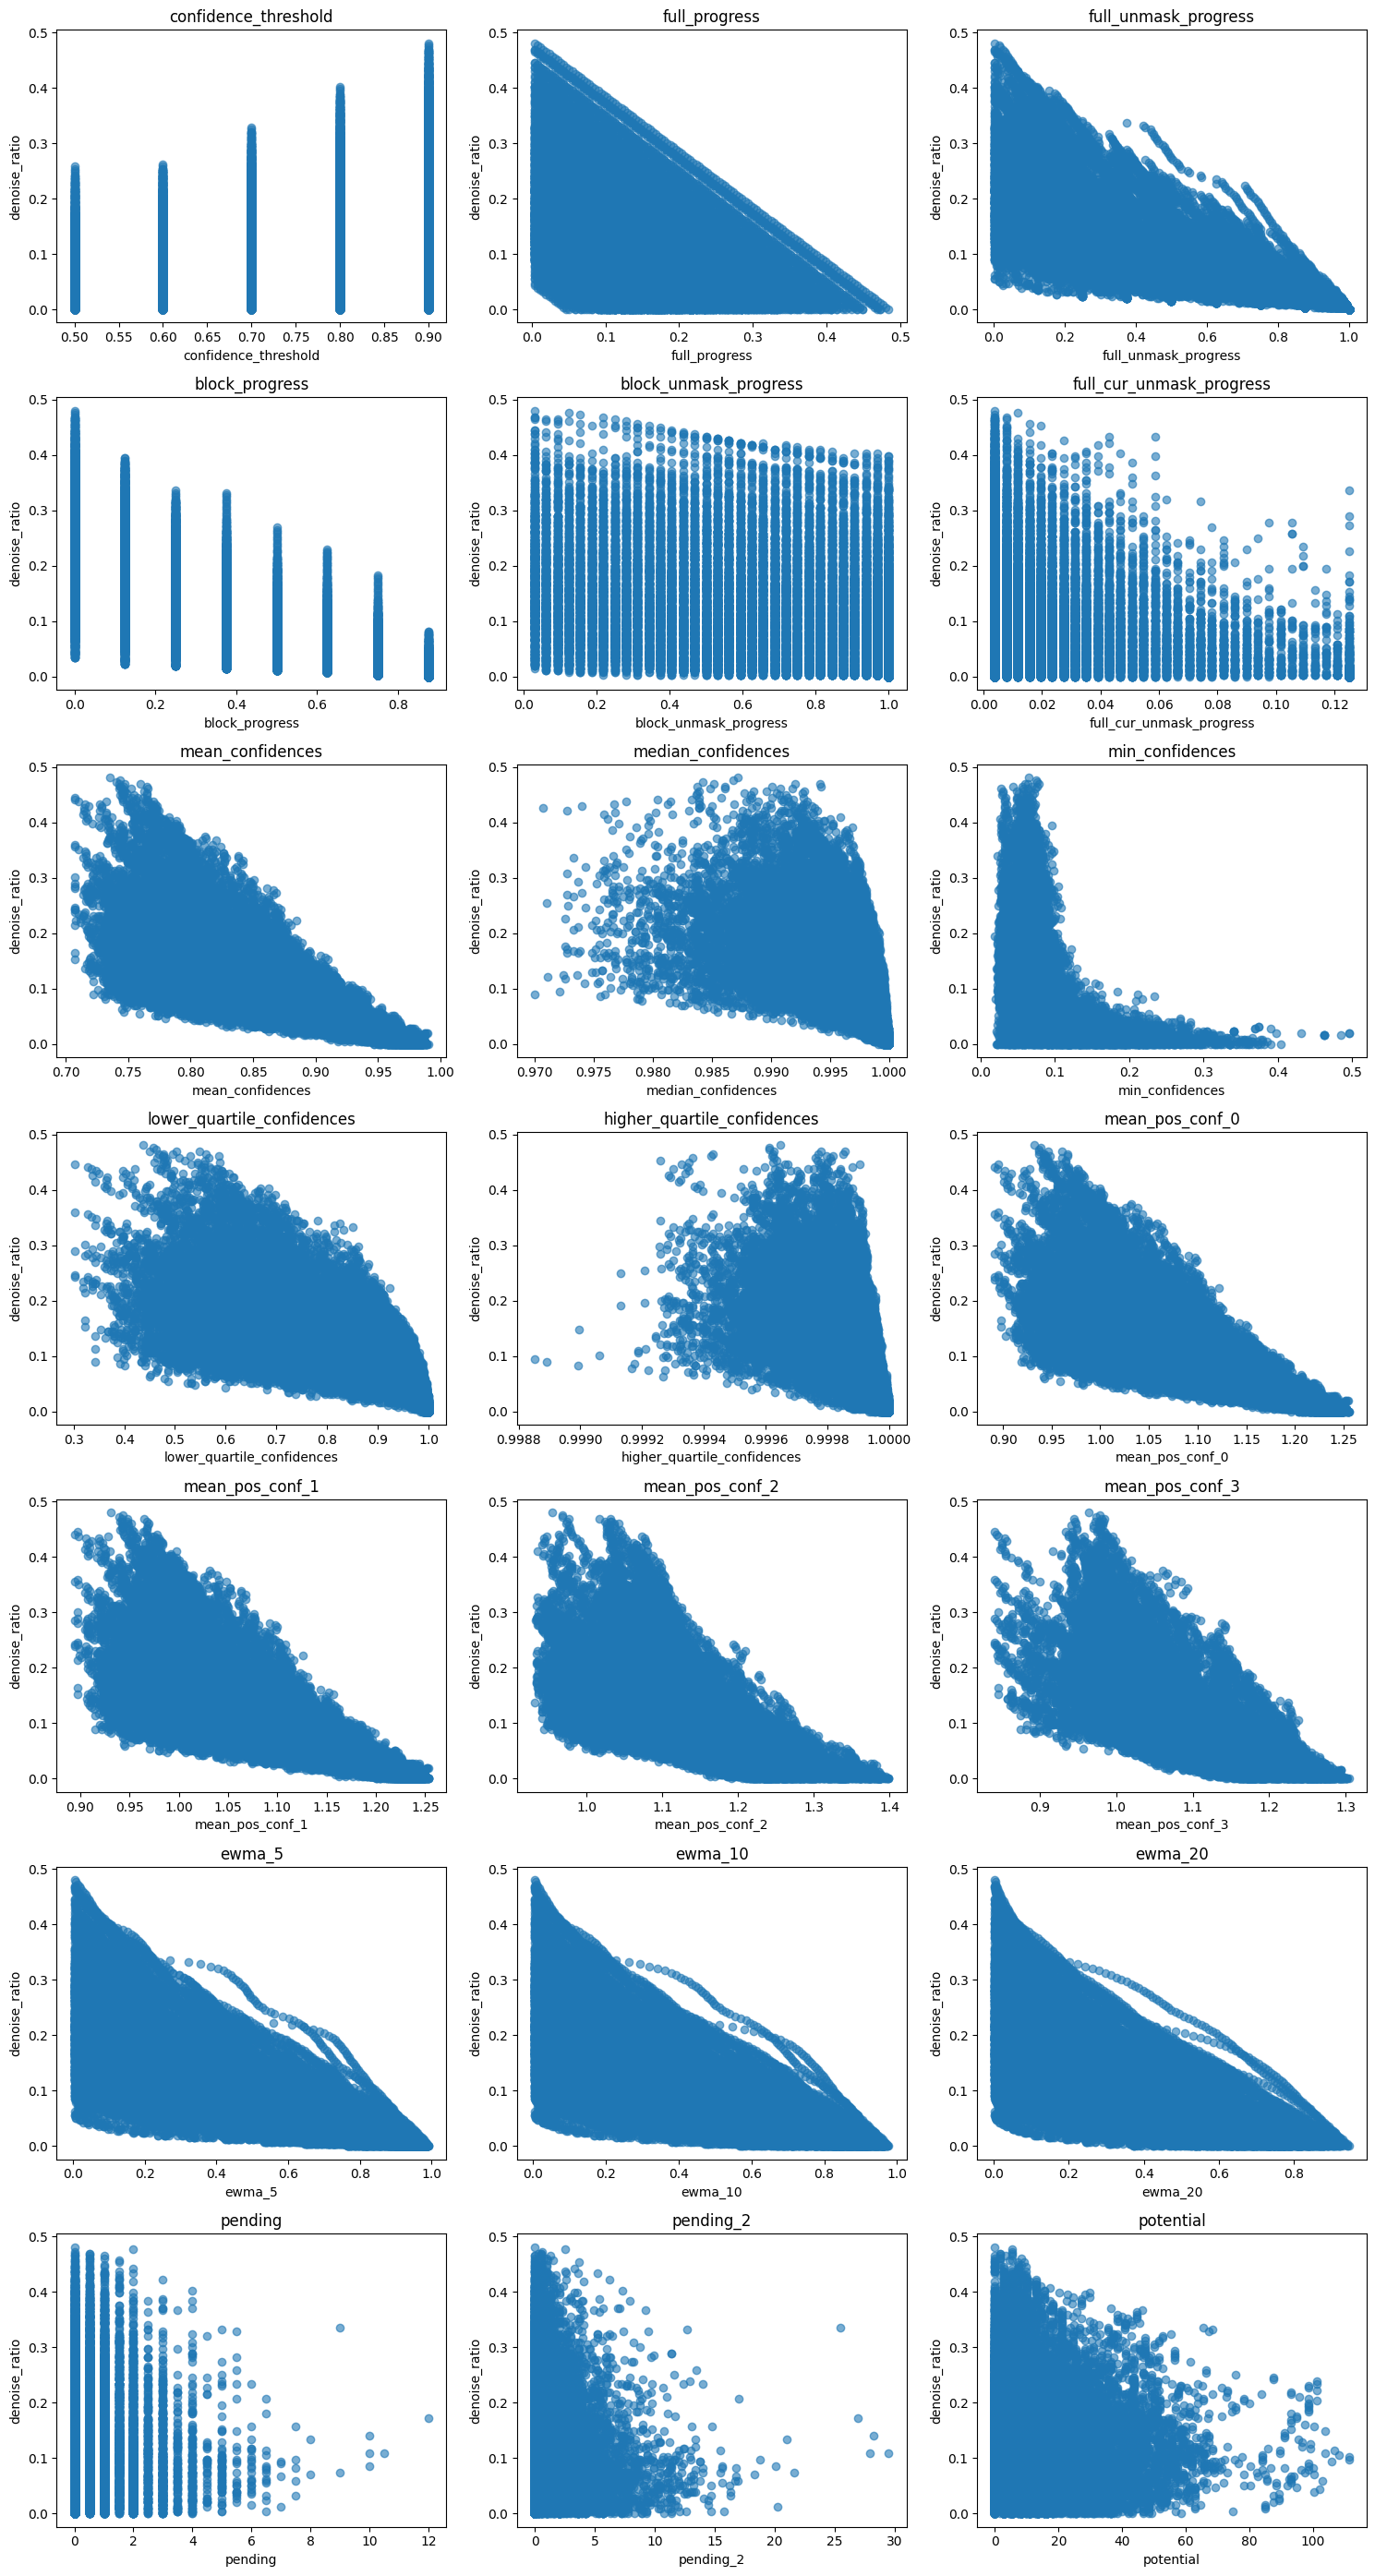

In [10]:
import math
import matplotlib.pyplot as plt

num_features = len(included_features)
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()  # flatten 2D axes array for easy iteration
label_col = "denoise_ratio"

for i, feature in enumerate(included_features):
    ax = axes[i]
    ax.scatter(df[feature], df[label_col], alpha=0.6)
    ax.set_xlabel(feature)
    ax.set_ylabel(label_col)
    ax.set_title(f"{feature}")

# hide any unused subplots (e.g., if num_features isn't a multiple of 4)
for j in range(len(included_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [11]:
X = df[included_features + ["output_length", "num_unmasked_tokens"]]
y = df["denoise_ratio"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [12]:
print(len(X_train))
print(len(X_test))

21523
5381


Inferrence: Make 5381 predictions in 5.560636520385742 ms
RMSE (steps): 7.2019
R^2   (steps): 0.9002
RMSE (ratio): 0.0281
R^2   (ratio): 0.9002


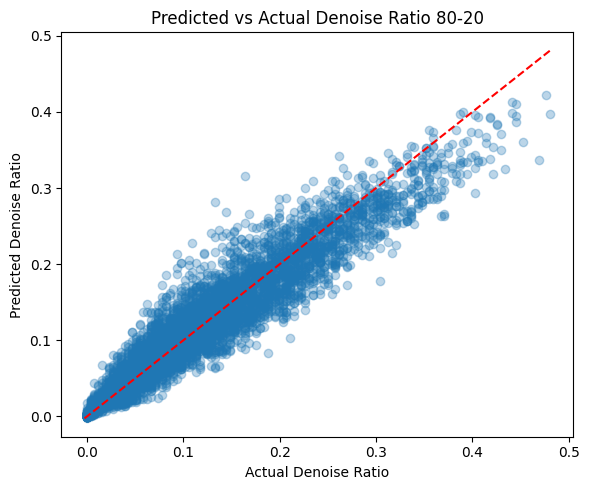

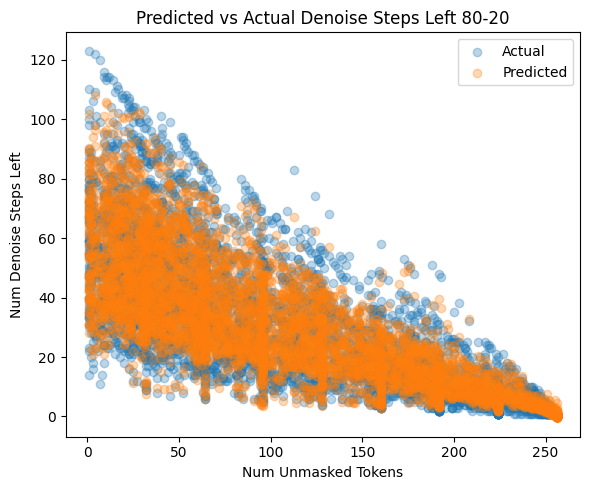

In [13]:
import lightgbm as lgb
import time

# train_from_scratch = True
# model_dir = "models/lgb_kiet"
# os.makedirs(model_dir, exist_ok=True)
# model_path = os.path.join(model_dir, "model2.bin")
# features_path = os.path.join(model_dir, "features.txt")
# if train_from_scratch and os.path.exists(model_path):
#     os.remove(model_path)
# if train_from_scratch and os.path.exists(features_path):
#     os.remove(features_path)

# if not os.path.exists(model_path):
#     model = lgb.LGBMRegressor(
#     objective="regression",
#     metric="rmse",
#     # n_estimators=200,
#     # learning_rate=0.1,
#     # num_leaves=64,
#     verbose=-1,
#     )
# else:
#     model = lgb.Booster(model_file=model_path)

model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    # n_estimators=200,
    # learning_rate=0.1,
    # num_leaves=64,
    verbose=-1,
)

# Training
model.fit(X_train[included_features], y_train)

# Predicting
start_time = time.time()
predictions = model.predict(X_test[included_features])
end_time = time.time()
print(f"Inferrence: Make {len(X_test)} predictions in {(end_time - start_time) * 1000} ms")

rmse_ratio = root_mean_squared_error(y_test, predictions)
r2_ratio = r2_score(y_test, predictions)

y_test_steps = y_test * X_test["output_length"]
y_pred_steps = predictions * X_test["output_length"]

rmse_steps = root_mean_squared_error(y_test_steps, y_pred_steps)
r2_steps = r2_score(y_test_steps, y_pred_steps)

print(f"RMSE (steps): {rmse_steps:.4f}")
print(f"R^2   (steps): {r2_steps:.4f}")
print(f"RMSE (ratio): {rmse_ratio:.4f}")
print(f"R^2   (ratio): {r2_ratio:.4f}")

# -------------------------------------------------
# Plots
# -------------------------------------------------
# Ratio scatter
title_suffix = "80-20"
plt.figure(figsize=(6, 5))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Actual Denoise Ratio")
plt.ylabel("Predicted Denoise Ratio")
plt.title(f"Predicted vs Actual Denoise Ratio {title_suffix}")
lim_lo = float(min(y_test.min(), predictions.min()))
lim_hi = float(max(y_test.max(), predictions.max()))
plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--")
plt.tight_layout()
plt.savefig("denoise_ratio_prediction.png", dpi=300)

# Steps vs num_unmasked_tokens
test_num_unmasked = X_test["num_unmasked_tokens"]
plt.figure(figsize=(6, 5))
plt.scatter(test_num_unmasked, y_test_steps, alpha=0.3, label="Actual")
plt.scatter(test_num_unmasked, y_pred_steps, alpha=0.3, label="Predicted")
plt.xlabel("Num Unmasked Tokens")
plt.ylabel("Num Denoise Steps Left")    
plt.title(f"Predicted vs Actual Denoise Steps Left {title_suffix}")
plt.legend()
plt.tight_layout()
plt.savefig("denoise_steps_prediction.png", dpi=300)

In [14]:
def train_experiment(included_features): 
    X = df[included_features + ["output_length", "num_unmasked_tokens"]]
    y = df["denoise_ratio"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
    model = lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        # n_estimators=200,
        # learning_rate=0.1,
        # num_leaves=64,
        verbose=-1,
    )

    # Training
    model.fit(X_train[included_features], y_train)

    start_time = time.time()
    predictions = model.predict(X_test[included_features])
    end_time = time.time()
    print(f"Inferrence: Make {len(X_test)} predictions in {(end_time - start_time) * 1000} ms")

    rmse_ratio = root_mean_squared_error(y_test, predictions)
    r2_ratio = r2_score(y_test, predictions)
    percentage_ratio = percentage_metrics(y_test, predictions)

    y_test_steps = y_test * X_test["output_length"]
    y_pred_steps = predictions * X_test["output_length"]


    rmse_steps = root_mean_squared_error(y_test_steps, y_pred_steps)
    r2_steps = r2_score(y_test_steps, y_pred_steps)
    percentage_steps = percentage_metrics(y_test_steps, y_pred_steps)

    print(f"RMSE (steps): {rmse_steps:.4f}")
    print(f"R^2   (steps): {r2_steps:.4f}")
    print(f"Percentage (steps): {percentage_steps:.4f}")
    print(f"RMSE (ratio): {rmse_ratio:.4f}")
    print(f"R^2   (ratio): {r2_ratio:.4f}")
    print(f"Percentage (ratio): {percentage_ratio:.4f}")

    title_suffix = "80-20"
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, predictions, alpha=0.3)
    plt.xlabel("Actual Denoise Ratio")
    plt.ylabel("Predicted Denoise Ratio")
    plt.title(f"Predicted vs Actual Denoise Ratio {title_suffix}")
    lim_lo = float(min(y_test.min(), predictions.min()))
    lim_hi = float(max(y_test.max(), predictions.max()))
    plt.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--")
    plt.tight_layout()
    plt.savefig("denoise_ratio_prediction.png", dpi=300)

    # Steps vs num_unmasked_tokens
    test_num_unmasked = X_test["num_unmasked_tokens"]
    plt.figure(figsize=(6, 5))
    plt.scatter(test_num_unmasked, y_test_steps, alpha=0.3, label="Actual")
    plt.scatter(test_num_unmasked, y_pred_steps, alpha=0.3, label="Predicted")
    plt.xlabel("Num Unmasked Tokens")
    plt.ylabel("Num Denoise Steps Left")    
    plt.title(f"Predicted vs Actual Denoise Steps Left {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("denoise_steps_prediction.png", dpi=300)


included_features_1 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
]

included_features_2 = [ # Confidences statistic
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
]

included_features_3 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
]

included_features_4 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
]

included_features_5 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "pending"
]

included_features_51 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "pending"
]

included_features_52 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "pending",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
]

included_features_6 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
    "pending"
]

included_features_x = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20"
]

included_features_7 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
    "pending_2"
]

included_features_8 = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    "mean_pos_conf_0",
    "mean_pos_conf_1",	
    "mean_pos_conf_2",	
    "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
    "potential"
]
  

Inferrence: Make 5381 predictions in 4.348039627075195 ms
RMSE (steps): 11.8268
R^2   (steps): 0.7309
Percentage (steps): 0.2729
RMSE (ratio): 0.0462
R^2   (ratio): 0.7309
Percentage (ratio): 0.2729
Inferrence: Make 5381 predictions in 7.426977157592773 ms
RMSE (steps): 7.1877
R^2   (steps): 0.9006
Percentage (steps): 0.1710
RMSE (ratio): 0.0281
R^2   (ratio): 0.9006
Percentage (ratio): 0.1710
Inferrence: Make 5381 predictions in 7.407188415527344 ms
RMSE (steps): 7.3132
R^2   (steps): 0.8971
Percentage (steps): 0.1734
RMSE (ratio): 0.0286
R^2   (ratio): 0.8971
Percentage (ratio): 0.1734
Inferrence: Make 5381 predictions in 6.134748458862305 ms
RMSE (steps): 7.2433
R^2   (steps): 0.8991
Percentage (steps): 0.1718
RMSE (ratio): 0.0283
R^2   (ratio): 0.8991
Percentage (ratio): 0.1718
Inferrence: Make 5381 predictions in 5.093812942504883 ms
RMSE (steps): 7.2525
R^2   (steps): 0.8988
Percentage (steps): 0.1725
RMSE (ratio): 0.0283
R^2   (ratio): 0.8988
Percentage (ratio): 0.1725


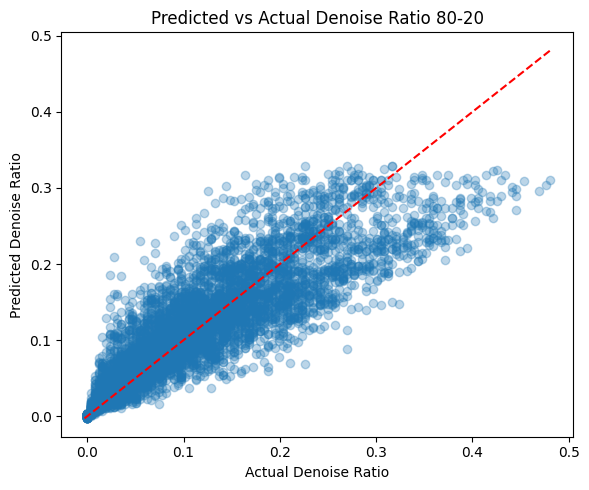

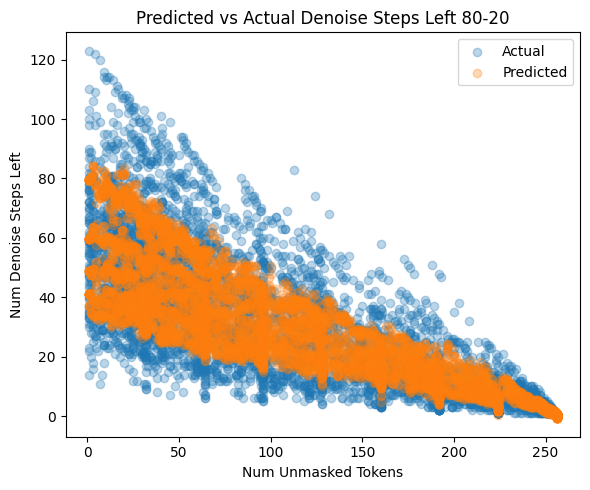

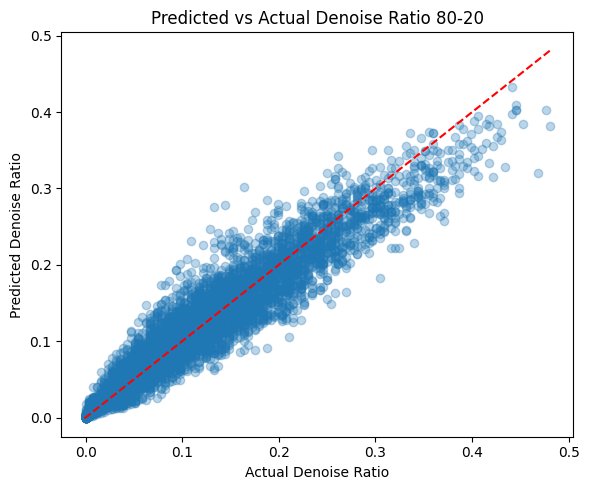

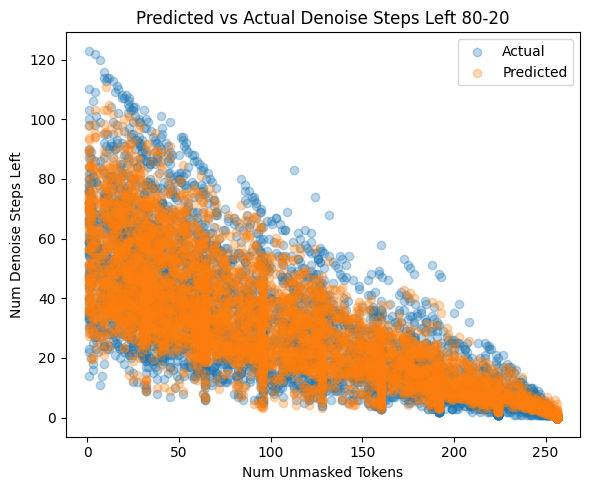

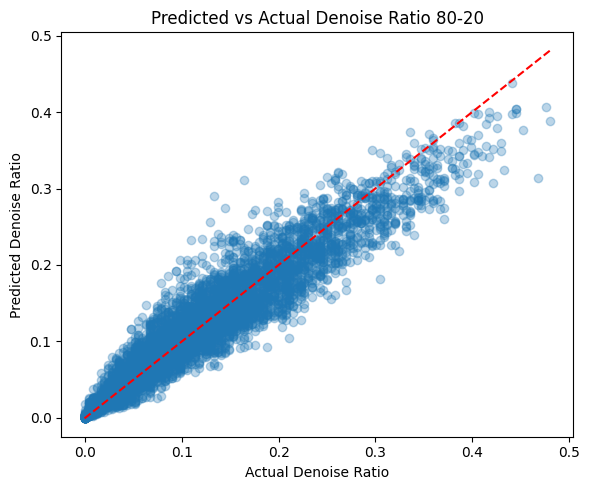

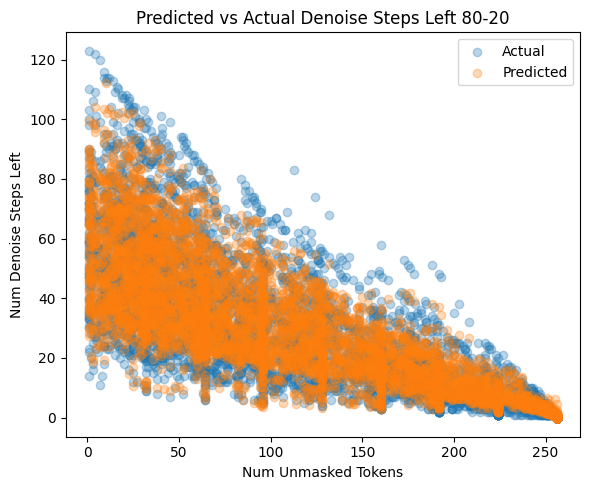

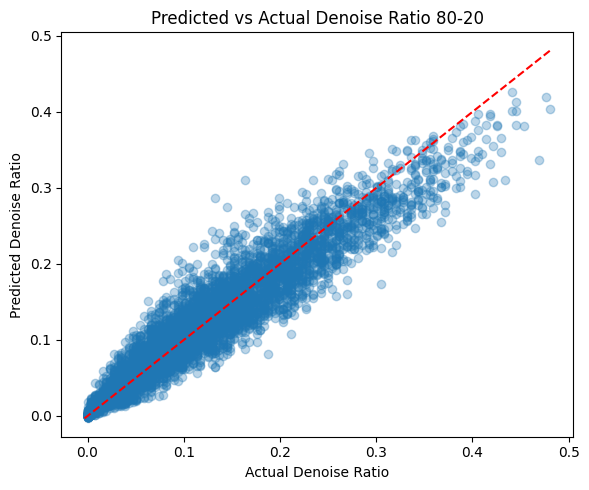

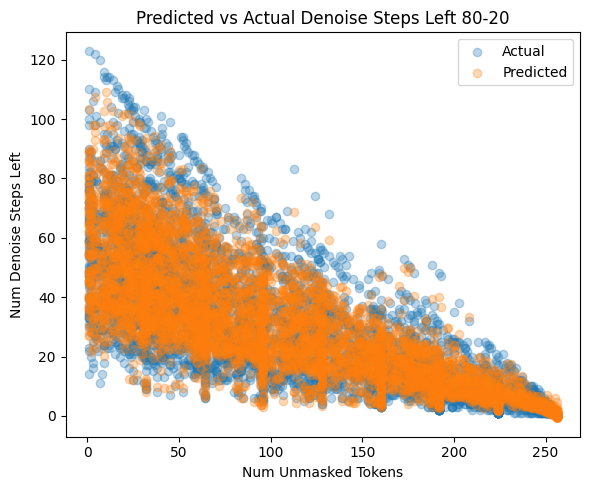

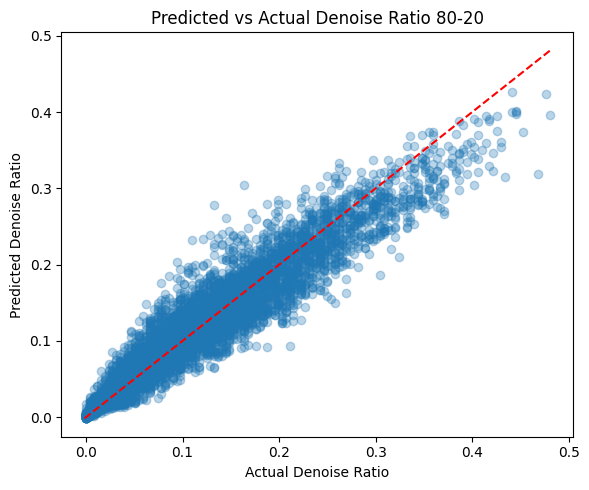

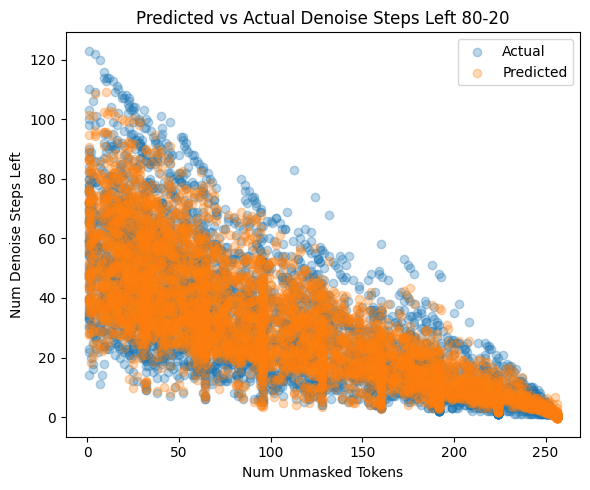

In [15]:
train_experiment(included_features_1)
train_experiment(included_features_6)
train_experiment(included_features_7)
train_experiment(included_features_8)
train_experiment(included_features_x)

Inferrence: Make 5381 predictions in 5.224704742431641 ms
RMSE (steps): 8.3228
R^2   (steps): 0.8667
Percentage (steps): 0.1931
RMSE (ratio): 0.0325
R^2   (ratio): 0.8667
Percentage (ratio): 0.1931
Inferrence: Make 5381 predictions in 8.627176284790039 ms
RMSE (steps): 8.5226
R^2   (steps): 0.8603
Percentage (steps): 0.1987
RMSE (ratio): 0.0333
R^2   (ratio): 0.8603
Percentage (ratio): 0.1987


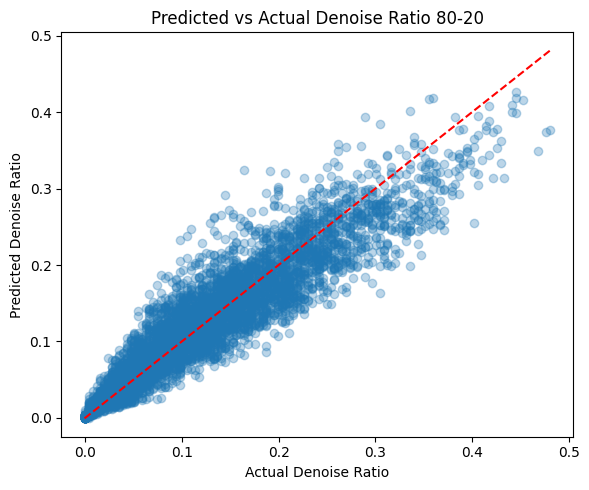

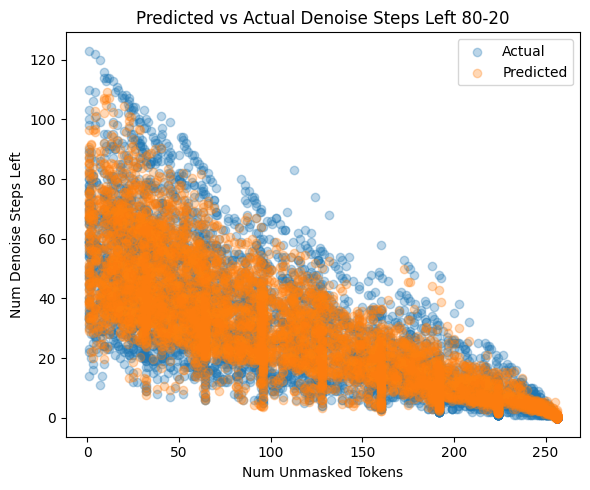

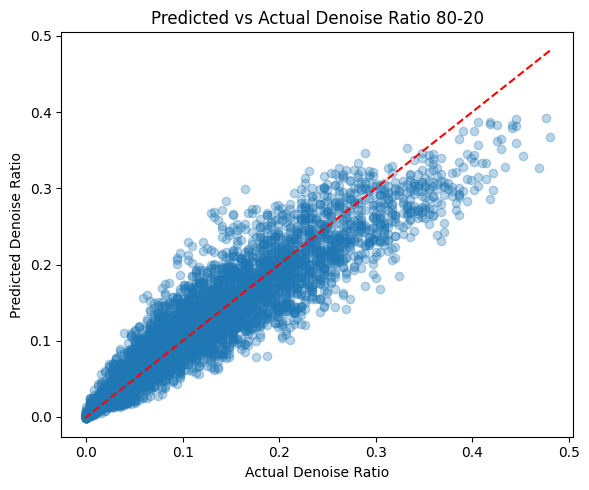

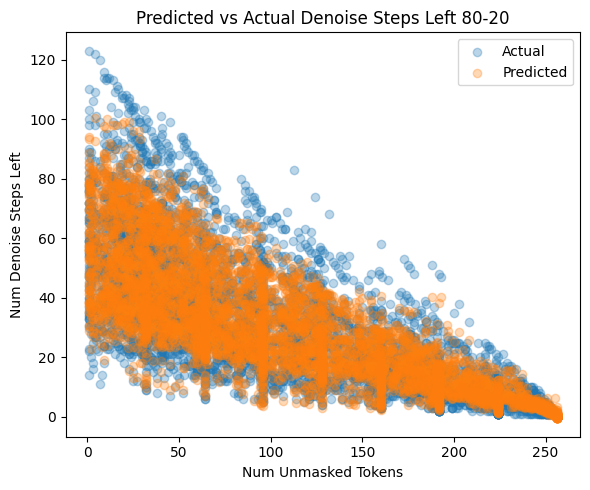

In [16]:
train_experiment(included_features_51)
train_experiment(included_features_52)

Inferrence: Make 5381 predictions in 5.958318710327148 ms
RMSE (steps): 8.5733
R^2   (steps): 0.8586
Percentage (steps): 0.1993
RMSE (ratio): 0.0335
R^2   (ratio): 0.8586
Percentage (ratio): 0.1993


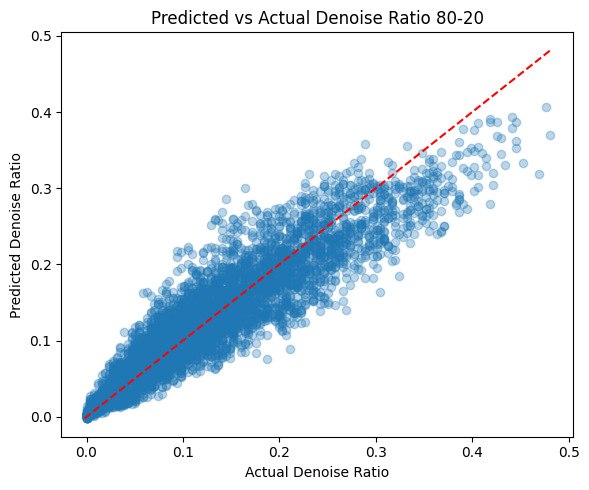

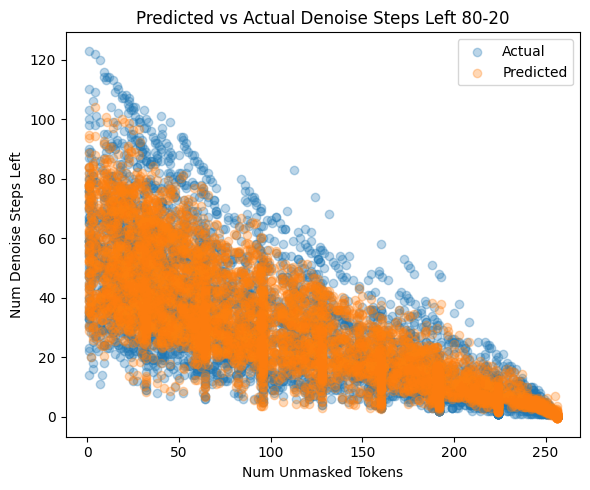

In [ ]:
included_features_T = [
    "confidence_threshold",
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "full_cur_unmask_progress",
    "mean_confidences", 
    "median_confidences", 
    "min_confidences",	
    "lower_quartile_confidences",
    "higher_quartile_confidences",	
    # "mean_pos_conf_0",
    # "mean_pos_conf_1",	
    # "mean_pos_conf_2",	
    # "mean_pos_conf_3",
    "ewma_5", 
    "ewma_10", 
    "ewma_20", 
    # "pending"
    # "potential"
]

train_experiment(included_features_T)

In [18]:
# numerator = np.abs(results_df[“y_test_steps”] - results_df[“y_pred_steps”]).sum()
#     denominator = np.abs(results_df[“y_test_steps”]).sum()
#     wmape = numerator / denominator